In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df1 = pd.read_csv("Year_2009_2010_Cleaned.csv")
df2 = pd.read_csv("Year_2010_2011_Cleaned.csv")

df = pd.concat([df1, df2], ignore_index=True)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [3]:
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["Quantity"]
      .sum()
      .reset_index()
)

daily_sales.columns = ["Date", "Demand"]

daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])

daily_sales.head()

,Date,Demand
0,2009-12-01,24403
1,2009-12-02,29751
2,2009-12-03,48032
3,2009-12-04,20057
4,2009-12-05,5119


In [4]:
train_data = daily_sales.iloc[:-30]
test_data = daily_sales.iloc[-30:]

print("Train:", train_data.shape)
print("Test:", test_data.shape)

Train: (574, 2)
Test: (30, 2)


In [5]:
prophet_train = train_data.rename(
    columns={
        "Date": "ds",
        "Demand": "y"
    }
)

In [6]:
prophet_model = Prophet()

prophet_model.fit(prophet_train)

12:58:40 - cmdstanpy - INFO - Chain [1] start processing
12:58:40 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
future = prophet_model.make_future_dataframe(
    periods=30
)

prophet_forecast = prophet_model.predict(future)

prophet_pred = (
    prophet_forecast["yhat"]
    .tail(30)
    .values
)

In [8]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    train_data[["Demand"]]
)

In [9]:
sequence_length = 30

X = []
y = []

for i in range(
    len(scaled_data) - sequence_length
):

    X.append(
        scaled_data[
            i:i + sequence_length
        ]
    )

    y.append(
        scaled_data[
            i + sequence_length
        ]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(544, 30, 1)
(544, 1)


In [10]:
class SalesDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, index):

        return self.X[index], self.y[index]

In [11]:
train_loader = DataLoader(
    SalesDataset(X, y),
    batch_size=32,
    shuffle=True
)

In [12]:
class LSTMForecast(
    pl.LightningModule
):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(
            64,
            1
        )

        self.loss_fn = nn.MSELoss()

    def forward(self, x):

        output, _ = self.lstm(x)

        output = output[:, -1, :]

        return self.fc(output)

    def training_step(
        self,
        batch,
        batch_idx
    ):

        x, y = batch

        prediction = self(x)

        loss = self.loss_fn(
            prediction,
            y
        )

        return loss

    def configure_optimizers(self):

        return torch.optim.Adam(
            self.parameters(),
            lr=0.001
        )

In [13]:
lstm_model = LSTMForecast()

trainer = pl.Trainer(
    max_epochs=20,
    accelerator="auto",
    devices=1
)

trainer.fit(
    lstm_model,
    train_loader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\HOME\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically

┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm    │ LSTM    │ 50.4 K │ train │     0 │
│ 1 │ fc      │ Linear  │     65 │ train │     0 │
│ 2 │ loss_fn │ MSELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 50.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 50.5 K                                                                                               
Total estimated model params size (MB): 0.202                                                                      
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\HOME\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\HOME\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\HOME\anaconda3\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of training batches (17) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_epochs=20` reached.


In [14]:
lstm_model.eval()

current_sequence = scaled_data[-30:]

lstm_predictions = []

for i in range(30):

    input_data = torch.tensor(
        current_sequence,
        dtype=torch.float32
    ).unsqueeze(0)

    with torch.no_grad():

        prediction = lstm_model(
            input_data
        ).numpy()[0][0]

    lstm_predictions.append(
        prediction
    )

    current_sequence = np.append(
        current_sequence[1:],
        [[prediction]],
        axis=0
    )

In [15]:
lstm_pred = scaler.inverse_transform(
    np.array(lstm_predictions)
    .reshape(-1, 1)
).flatten()

In [16]:
print("Prophet predictions:", len(prophet_pred))
print("LSTM predictions:", len(lstm_pred))

Prophet predictions: 30
LSTM predictions: 30


In [17]:
hybrid_pred = (
    prophet_pred + lstm_pred
) / 2

In [18]:
actual = test_data["Demand"].values

prophet_mae = mean_absolute_error(
    actual,
    prophet_pred
)

lstm_mae = mean_absolute_error(
    actual,
    lstm_pred
)

hybrid_mae = mean_absolute_error(
    actual,
    hybrid_pred
)

print(
    "Prophet MAE:",
    round(prophet_mae, 2)
)

print(
    "LSTM MAE:",
    round(lstm_mae, 2)
)

print(
    "Hybrid MAE:",
    round(hybrid_mae, 2)
)

Prophet MAE: 12345.86
LSTM MAE: 13330.89
Hybrid MAE: 12589.32


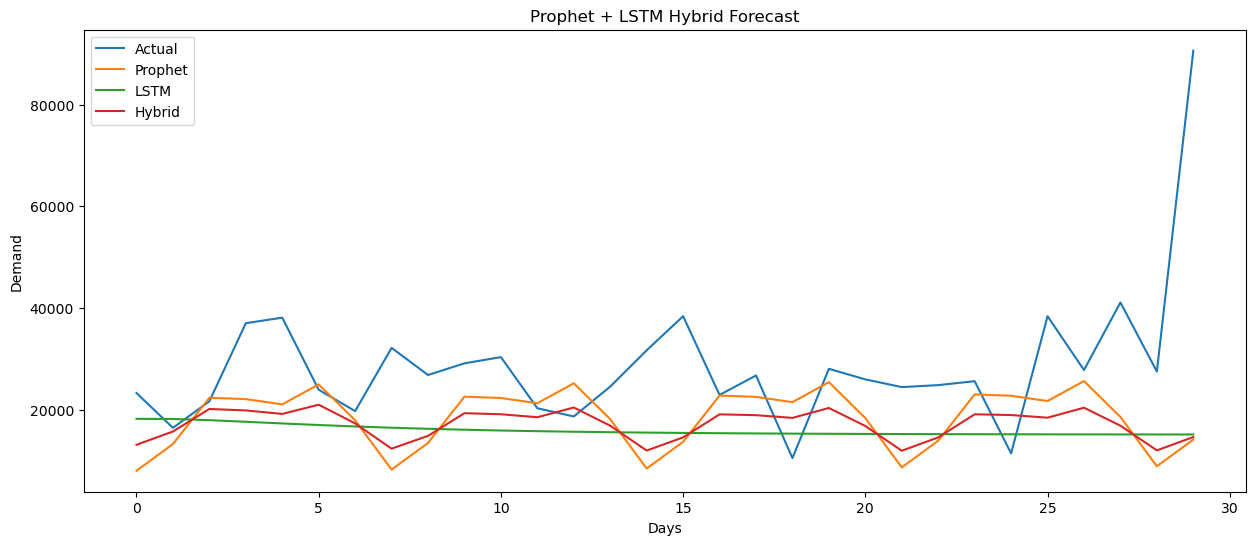

In [19]:
plt.figure(figsize=(15, 6))

plt.plot(
    actual,
    label="Actual"
)

plt.plot(
    prophet_pred,
    label="Prophet"
)

plt.plot(
    lstm_pred,
    label="LSTM"
)

plt.plot(
    hybrid_pred,
    label="Hybrid"
)

plt.title(
    "Prophet + LSTM Hybrid Forecast"
)

plt.xlabel("Days")

plt.ylabel("Demand")

plt.legend()

plt.show()

In [20]:
results = pd.DataFrame({

    "Date": test_data["Date"].values,

    "Actual": actual,

    "Prophet_Prediction": prophet_pred,

    "LSTM_Prediction": lstm_pred,

    "Hybrid_Prediction": hybrid_pred

})

results.to_csv(
    "hybrid_forecast_results.csv",
    index=False
)

results.head()

,Date,Actual,Prophet_Prediction,LSTM_Prediction,Hybrid_Prediction
0,2011-11-06,23288,8009.596240,18214.353516,13111.974878
1,2011-11-07,16443,13253.978288,18186.640625,15720.309456
2,2011-11-08,21658,22356.290964,17947.380859,20151.835912
3,2011-11-09,37016,22087.758675,17632.328125,19860.043400
4,2011-11-10,38098,21052.411106,17304.685547,19178.548327
